# Data inspection

In [21]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append("/home/johmathe/bgbench")
os.environ["PYTHONPATH"] = os.pathsep.join(sys.path)
from src.data import omics_datamodule


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Preparing dataset...


pancancer_proteomics.xlsx: 100%|██████████| 72.7M/72.7M [00:00<00:00, 76.6MiB/s]


pancancer_drug_response.csv.gz: 100%|██████████| 43.1M/43.1M [00:06<00:00, 7.12MiB/s]


Loading data...
Converting data to numeric...
Number of valid protein columns: 8502
Imputing missing values...
Selecting nodes...
Calculating adjacency matrix...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  1000
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.056575  0.176081       0.757478  149.843708  139.487986   
1       1  0.056575  0.176081       0.757478  149.843708  139.487986   
2       2  0.952936  -0.82575       0.955636   44.274353   29.777725   
3       3  0.976446 -0.969123       0.972126   18.327404    7.775536   
4       3  0.976446 -0.969123       0.972126   18.327404    7.775536   
5       4  0.954002 -1.011708       0.941237    9.196955    2.291391   
6       5  0.953268 -1.020137       0.941779    5.197715    0.775678   
7       5  0.953268 -1.020137       0.941779    5.197715    0.775678   
8       6  0.960731 -1.015692       0.949949    3.175974    0.281278   
9       7  0.941748 -1.03982

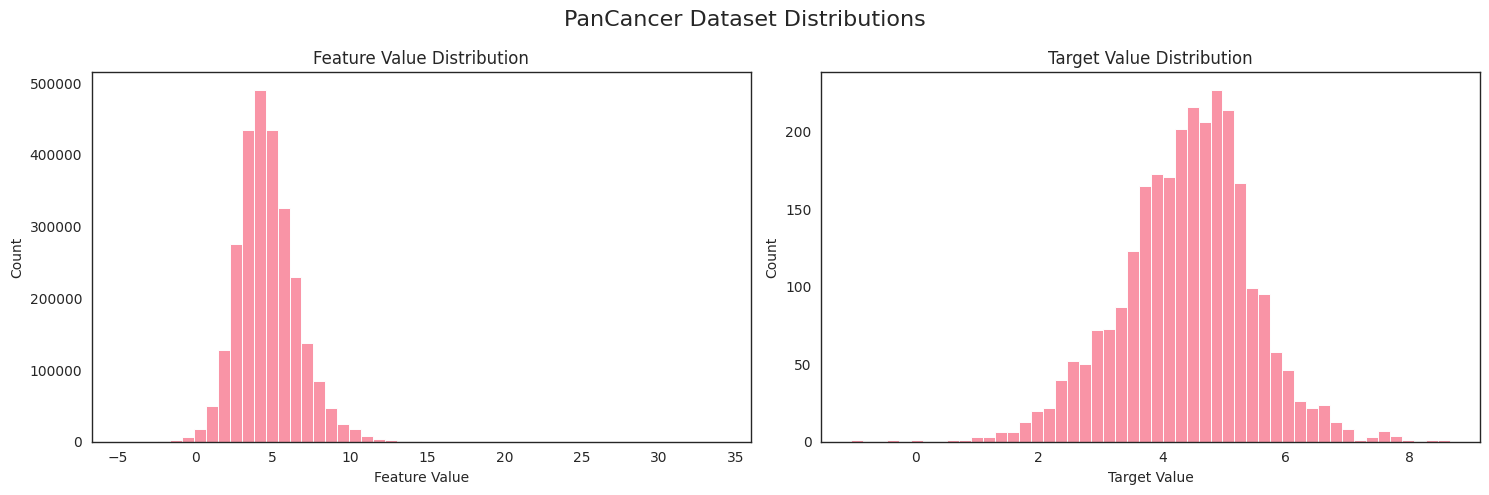


PanCancer Dataset Statistics:
Number of samples: 2725
Number of features: 1000

Target Statistics:
Mean: 4.39
Std: 1.06
Min: -1.04
Max: 8.66


In [ ]:

# Set style
sns.set_palette("husl")

def plot_dataset_distributions(datamodule_class, title):
    """Plot feature and target distributions for a dataset."""
    # Initialize datamodule
    datamodule = datamodule_class()
    datamodule.prepare_data()
    
    # Load data
    selected_data = pd.read_parquet(datamodule.selected_data_path)
    targets = np.load(datamodule.targets_path)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{title} Dataset Distributions', fontsize=16)
    
    # Plot feature distributions
    sns.histplot(data=selected_data.values.flatten(), ax=ax1, bins=50)
    ax1.set_title('Feature Value Distribution')
    ax1.set_xlabel('Feature Value')
    ax1.set_ylabel('Count')
    
    # Plot target distribution
    sns.histplot(data=targets, ax=ax2, bins=50)
    ax2.set_title('Target Value Distribution')
    ax2.set_xlabel('Target Value')
    ax2.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    print(f"Number of samples: {len(targets)}")
    print(f"Number of features: {selected_data.shape[1]}")
    print(f"\nTarget Statistics:")
    print(f"Mean: {np.mean(targets):.2f}")
    print(f"Std: {np.std(targets):.2f}")
    print(f"Min: {np.min(targets):.2f}")
    print(f"Max: {np.max(targets):.2f}")

# Plot distributions for each dataset
plot_dataset_distributions(omics_datamodule.MortrPacDataModule, "MortrPac")
plot_dataset_distributions(omics_datamodule.PanCancerDataModule, "PanCancer")
plot_dataset_distributions(omics_datamodule.AddNeuroMedOmicsDataModule, "AddNeuroMed")